In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached pillow-12.2.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.1 MB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
df = pd.read_csv('../../../results/Subtle_experiment_results.csv',index_col=0)
print(df)

FileNotFoundError: [Errno 2] No such file or directory: '../../../results/Subtle_experiment_results.csv'

# Comparaison resultats sur toxicité complete Subtilité

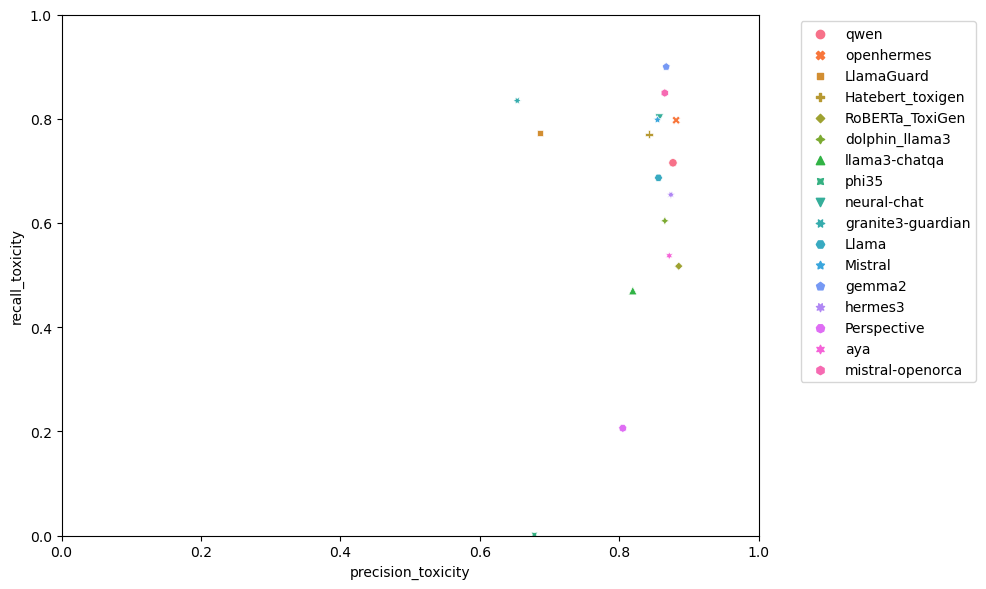

In [18]:
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
plt.ylim(0, 1)

plot = sns.scatterplot(data=df, x="precision_toxicity", y="recall_toxicity",style='model',hue='model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # ajuste automatiquement la taille de la figure

plt.show()

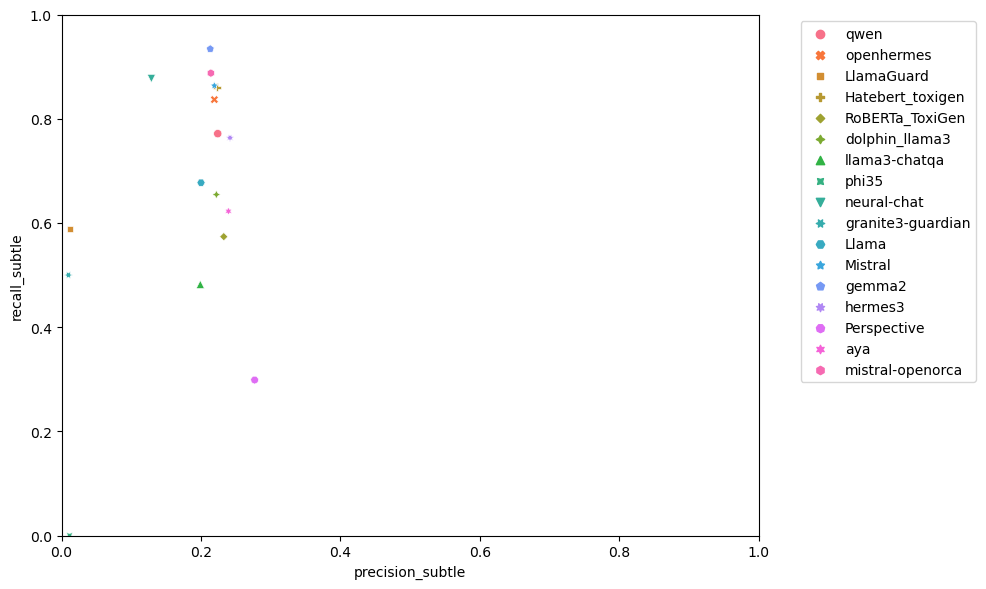

In [19]:
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
plt.ylim(0, 1)

plot = sns.scatterplot(data=df, x="precision_subtle", y="recall_subtle",style='model',hue='model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # ajuste automatiquement la taille de la figure

plt.show()

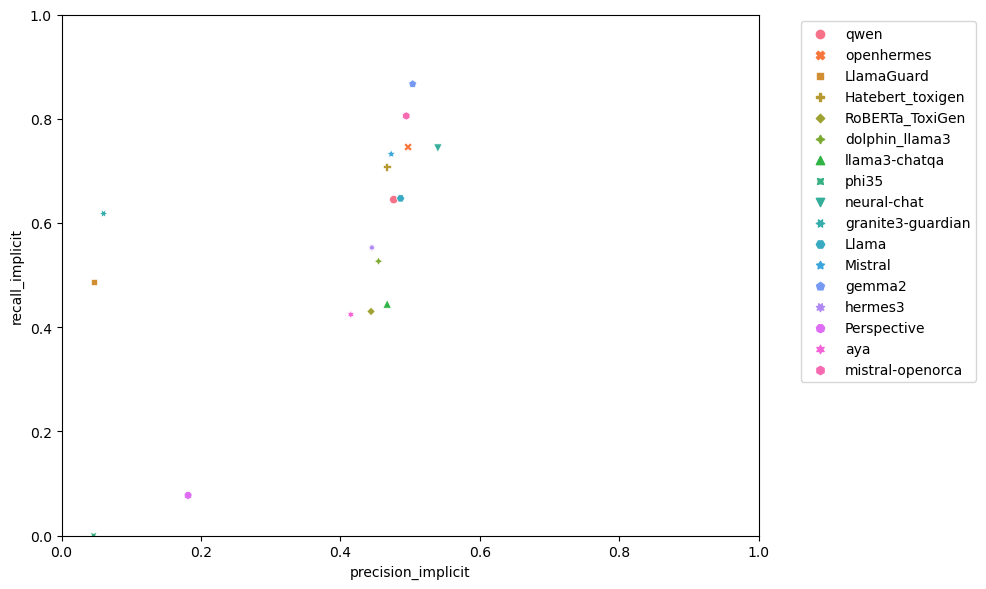

In [20]:
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
plt.ylim(0, 1)

plot = sns.scatterplot(data=df, x="precision_implicit", y="recall_implicit",style='model',hue='model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # ajuste automatiquement la taille de la figure

plt.show()

# Toxigen

In [28]:
toxigen_results_df = pd.read_csv('../../../results/Toxigen/toxigen_results.csv')
print(toxigen_results_df)


    Unnamed: 0            model  precision    recall        f1  accuracy
0            0             qwen   0.879793  0.457642  0.602093  0.698772
1            1           Falcon   0.000000  0.000000  0.000000       NaN
2            2       OpenHermes   0.871742  0.569955  0.689262  0.744111
3            3       NeuralChat   0.807337  0.646123  0.717789  0.746987
4            4   dolphin_llama3   0.889676  0.393994  0.546132  0.673738
5            5  MistralOpenOrca   0.820513  0.670615  0.738030  0.758939
6            6            Llama   0.857635  0.557597  0.675811  0.733594
7            7          Mistral   0.784245  0.751905  0.767735  0.773438
8            8           gemma2   0.792012  0.706792  0.746979  0.761554
9            9          hermes3   0.871632  0.493052  0.629831  0.711384
10          10      Perspective   0.494612  0.102892  0.170347  0.500949
11          11              aya   0.778099  0.663375  0.716172  0.738183
12          12     Llama3ChatQA   0.920993  0.26112

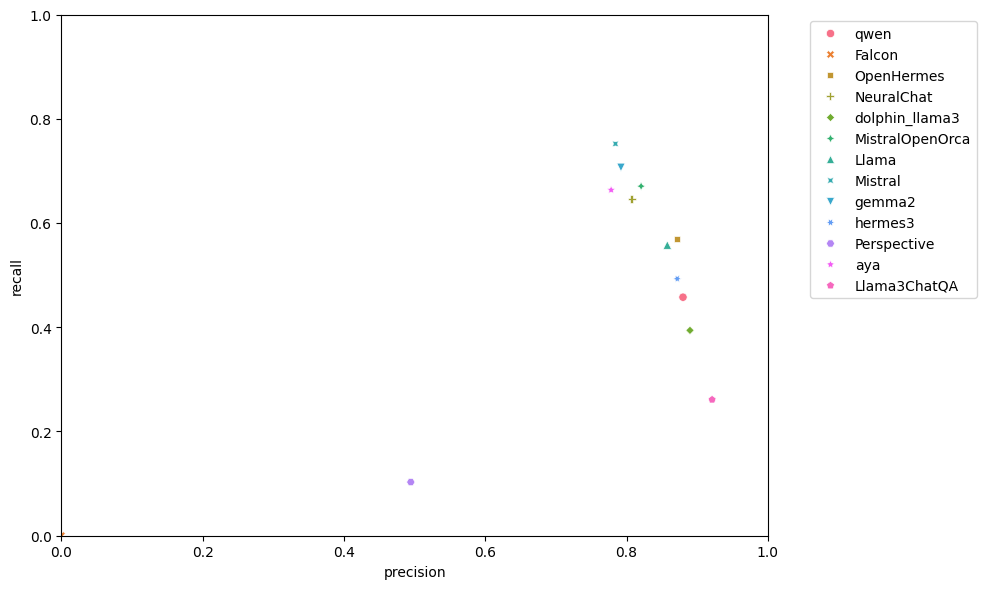

In [29]:
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
plt.ylim(0, 1)

plot = sns.scatterplot(data=toxigen_results_df, x="precision", y="recall",style='model',hue='model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # ajuste automatiquement la taille de la figure

plt.show()

In [5]:
biais_df = pd.read_csv('../../../Data/cad.tsv',sep='\t')



In [ ]:
print(biais_df.columns)
print(len(biais_df))
pd.set_option("display.max_columns", None)
# print(biais_df.head(3))
print(biais_df['annotation_Primary'].unique())
print(biais_df[biais_df['annotation_Primary'] == 'AffiliationDirectedAbuse'].head(3))
# bias_df_filtered = biais_df[['original_text','ground_truth','status','perturbed_text','unique_src_instance_identifier']]
# bias_df_filtered.to_csv('../../../Data/attaques.csv')

Index(['id', 'info_id', 'info_subreddit', 'info_subreddit_id',
       'info_id.parent', 'info_id.link', 'info_thread.id', 'info_order',
       'info_image.saved', 'annotation_Primary', 'annotation_Secondary',
       'annotation_Context', 'annotation_Target',
       'annotation_Target_top.level.category', 'annotation_highlighted',
       'meta_author', 'meta_created_utc', 'meta_date', 'meta_day',
       'meta_permalink', 'split', 'subreddit_seen', 'meta_text'],
      dtype='object')
27494
      id      info_id   info_subreddit info_subreddit_id info_id.parent  \
0  cad_1  alywla-post            Drama          t5_2rd2l            NaN   
1  cad_2  am027u-post       conspiracy          t5_2qh4r            NaN   
2  cad_3  am80hq-post  subredditcancer          t5_2yv5q            NaN   

  info_id.link  info_thread.id info_order info_image.saved annotation_Primary  \
0          NaN               2    02-post                0            Neutral   
1          NaN               3    03-post   

In [3]:
import os
import glob
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


# =========================
# CONFIG
# =========================

DATASET_PATH = "../../../Data/biaisDataset.csv"  # adapte le chemin
RESULTS_DIR = "../../../results/biais/"                    # dossier avec les CSV des modèles
OUTPUT_DIR = "../../../results/metrics_outputs"

ID_COL_DATASET = "id"
ID_COL_RESULTS = "message_id"

TRUE_TOX_COL = "toxicity"
TRUE_THRESHOLD = 0.5
PRED_THRESHOLD = 0.5

os.makedirs(OUTPUT_DIR, exist_ok=True)


# Colonnes identitaires de ton dataset
IDENTITY_COLS = [
    "male", "female", "transgender", "other_gender",
    "heterosexual", "homosexual_gay_or_lesbian", "bisexual",
    "other_sexual_orientation",
    "christian", "jewish", "muslim", "hindu", "buddhist", "atheist",
    "other_religion",
    "black", "white", "asian", "latino", "other_race_or_ethnicity",
    "physical_disability", "intellectual_or_learning_disability",
    "psychiatric_or_mental_illness", "other_disability"
]


# =========================
# UTILS
# =========================

def find_score_column(results_df):
    """
    Essaie de trouver automatiquement la colonne contenant le score du modèle.
    Adapte la liste si tes fichiers ont un autre nom de colonne.
    """
    possible_cols = [
        "score",
        "toxicity_score",
        "pred_score",
        "prediction",
        "toxicity",
        "model_score",
        "probability",
        "prob"
    ]

    for col in possible_cols:
        if col in results_df.columns:
            return col

    numeric_cols = results_df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != ID_COL_RESULTS]

    if len(numeric_cols) == 1:
        return numeric_cols[0]

    raise ValueError(
        f"Impossible de trouver automatiquement la colonne de score. "
        f"Colonnes disponibles : {results_df.columns.tolist()}"
    )


def safe_metrics(y_true, y_pred):
    """
    Calcule precision, recall, f1, accuracy.
    zero_division=0 évite les crashes si aucun positif prédit.
    """
    return {
        "n": len(y_true),
        "positives_true": int(y_true.sum()),
        "positives_pred": int(y_pred.sum()),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }


def evaluate_model(dataset_df, results_path):
    model_name = os.path.splitext(os.path.basename(results_path))[0]

    results_df = pd.read_csv(results_path)

    if ID_COL_RESULTS not in results_df.columns:
        raise ValueError(
            f"{results_path} ne contient pas la colonne {ID_COL_RESULTS}. "
            f"Colonnes disponibles : {results_df.columns.tolist()}"
        )

    score_col = find_score_column(results_df)

    # Harmoniser les types AVANT le merge
    dataset_df = dataset_df.copy()
    results_df = results_df.copy()

    dataset_df[ID_COL_DATASET] = dataset_df[ID_COL_DATASET].astype(str).str.strip()
    results_df[ID_COL_RESULTS] = results_df[ID_COL_RESULTS].astype(str).str.strip()

    # Garde seulement l'id + score
    results_df = results_df[[ID_COL_RESULTS, score_col]].copy()
    results_df = results_df.rename(columns={score_col: "model_score"})

    merged = dataset_df.merge(
        results_df,
        left_on=ID_COL_DATASET,
        right_on=ID_COL_RESULTS,
        how="inner"
    )

    if len(merged) == 0:
        print("Exemples dataset ids:", dataset_df[ID_COL_DATASET].head().tolist())
        print("Exemples results ids:", results_df[ID_COL_RESULTS].head().tolist())
        raise ValueError(f"Aucun message matché pour {model_name}.")

    merged["y_true"] = (merged[TRUE_TOX_COL] > TRUE_THRESHOLD).astype(int)
    merged["y_pred"] = (merged["model_score"] >= PRED_THRESHOLD).astype(int)

    # Une seule ligne finale pour ce modèle
    row = {
        "model": model_name,
        "coverage_n": len(merged),
        "coverage_ratio": len(merged) / len(dataset_df),
    }

    # =========================
    # GLOBAL
    # =========================

    global_metrics = safe_metrics(merged["y_true"], merged["y_pred"])

    for metric_name, metric_value in global_metrics.items():
        row[f"{metric_name}_GLOBAL"] = metric_value

    row["score_mean_on_true_toxic_GLOBAL"] = merged.loc[
        merged["y_true"] == 1, "model_score"
    ].mean()

    row["score_median_on_true_toxic_GLOBAL"] = merged.loc[
        merged["y_true"] == 1, "model_score"
    ].median()

    row["score_mean_on_true_non_toxic_GLOBAL"] = merged.loc[
        merged["y_true"] == 0, "model_score"
    ].mean()

    row["score_median_on_true_non_toxic_GLOBAL"] = merged.loc[
        merged["y_true"] == 0, "model_score"
    ].median()

    # =========================
    # PAR IDENTITÉ
    # =========================

    for identity_col in IDENTITY_COLS:
        if identity_col not in merged.columns:
            continue

        subset = merged[merged[identity_col] > 0.5].copy()

        if len(subset) == 0:
            # Optionnel : créer quand même des colonnes vides
            row[f"n_{identity_col}"] = 0
            row[f"f1_{identity_col}"] = None
            row[f"precision_{identity_col}"] = None
            row[f"recall_{identity_col}"] = None
            row[f"accuracy_{identity_col}"] = None
            row[f"score_mean_on_true_toxic_{identity_col}"] = None
            row[f"score_median_on_true_toxic_{identity_col}"] = None
            row[f"score_mean_on_true_non_toxic_{identity_col}"] = None
            row[f"score_median_on_true_non_toxic_{identity_col}"] = None
            continue

        identity_metrics = safe_metrics(subset["y_true"], subset["y_pred"])

        for metric_name, metric_value in identity_metrics.items():
            row[f"{metric_name}_{identity_col}"] = metric_value

        row[f"score_mean_on_true_toxic_{identity_col}"] = subset.loc[
            subset["y_true"] == 1, "model_score"
        ].mean()

        row[f"score_median_on_true_toxic_{identity_col}"] = subset.loc[
            subset["y_true"] == 1, "model_score"
        ].median()

        row[f"score_mean_on_true_non_toxic_{identity_col}"] = subset.loc[
            subset["y_true"] == 0, "model_score"
        ].mean()

        row[f"score_median_on_true_non_toxic_{identity_col}"] = subset.loc[
            subset["y_true"] == 0, "model_score"
        ].median()

    metrics_df = pd.DataFrame([row])

    return metrics_df, merged

# =========================
# MAIN
# =========================

dataset_df = pd.read_csv(DATASET_PATH)

# Important si les ids sont parfois lus comme int dans un fichier et str dans l'autre
dataset_df[ID_COL_DATASET] = dataset_df[ID_COL_DATASET].astype(str)

result_files = glob.glob(os.path.join(RESULTS_DIR, "*.csv"))

all_metrics = []
all_merged = {}

for results_path in result_files:
    print(f"Évaluation de {results_path}")
    if 'biais_results.csv' in results_path:
        continue
    metrics_df, merged_df = evaluate_model(dataset_df, results_path)

    model_name = os.path.splitext(os.path.basename(results_path))[0]

    all_metrics.append(metrics_df)
    all_merged[model_name] = merged_df

final_metrics_df = pd.concat(all_metrics, ignore_index=True)

final_metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "all_models_metrics.csv"),
    index=False
)

print(final_metrics_df)

Évaluation de ../../../results/biais/Hermes3.csv
Évaluation de ../../../results/biais/Aya.csv
Évaluation de ../../../results/biais/Qwen25.csv
Évaluation de ../../../results/biais/biais_results.csv
Évaluation de ../../../results/biais/NeuralChat.csv
Évaluation de ../../../results/biais/DolphinLlama.csv
Évaluation de ../../../results/biais/MistralOpenOrca.csv
Évaluation de ../../../results/biais/Llama.csv
Évaluation de ../../../results/biais/Roberta.csv
Évaluation de ../../../results/biais/Mistral.csv
Évaluation de ../../../results/biais/gemma2.csv
Évaluation de ../../../results/biais/Perspective.csv
Évaluation de ../../../results/biais/aya.csv
Évaluation de ../../../results/biais/Llama3ChatQA.csv
              model  coverage_n  coverage_ratio  n_GLOBAL  \
0           Hermes3     1367424        0.683877   1367424   
1               Aya     1038144        0.519198   1038144   
2            Qwen25      960032        0.480132    960032   
3        NeuralChat     1043584        0.521918   1

/home/theophileberteloot/Bureau/Recherche/PhD/ToxicityLimitation/venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_2633184/2223710293.py:234: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_metrics_df = pd.concat(all_metrics, ignore_index=True)


In [4]:
import os
import glob
import pandas as pd
import numpy as np


# =========================
# CONFIG
# =========================

EXPERIMENTS_DIR = "../../../results/experiments/"
OUTPUT_PATH = "../../../results/experiments/global_model_scores.csv"

MODEL_COL = "model"

# Tu peux changer ça selon tes noms de colonnes
F1_PATTERNS = ["f1"]


# =========================
# EXTRACTION
# =========================

def detect_f1_columns(df, patterns=F1_PATTERNS):
    """
    Détecte automatiquement les colonnes contenant des scores F1.
    Par défaut, toute colonne contenant 'f1' est récupérée.
    """
    f1_cols = []

    for col in df.columns:
        col_lower = col.lower()
        if any(pattern.lower() in col_lower for pattern in patterns):
            f1_cols.append(col)

    return f1_cols


def load_experiment_csv(path):
    """
    Charge un CSV d'expérience et garde seulement :
    - le modèle
    - les colonnes F1
    - le nom de l'expérience
    """
    experiment_name = os.path.splitext(os.path.basename(path))[0]

    df = pd.read_csv(path)

    if MODEL_COL not in df.columns:
        raise ValueError(
            f"Le fichier {path} ne contient pas la colonne '{MODEL_COL}'. "
            f"Colonnes disponibles : {df.columns.tolist()}"
        )

    f1_cols = detect_f1_columns(df)

    if len(f1_cols) == 0:
        raise ValueError(
            f"Aucune colonne F1 détectée dans {path}. "
            f"Colonnes disponibles : {df.columns.tolist()}"
        )

    keep_cols = [MODEL_COL] + f1_cols
    df = df[keep_cols].copy()

    df["experiment"] = experiment_name

    return df, f1_cols


def load_all_experiments(experiments_dir):
    all_rows = []
    all_f1_cols = set()

    paths = glob.glob(os.path.join(experiments_dir, "*.csv"))

    if len(paths) == 0:
        raise ValueError(f"Aucun CSV trouvé dans {experiments_dir}")

    for path in paths:
        df_exp, f1_cols = load_experiment_csv(path)

        all_rows.append(df_exp)
        all_f1_cols.update(f1_cols)

    combined_df = pd.concat(all_rows, ignore_index=True)

    return combined_df, sorted(all_f1_cols)


# =========================
# SCORING FORMULAS
# =========================

def score_mean(row, f1_cols):
    """
    Score global = moyenne simple de tous les F1 disponibles.
    """
    values = row[f1_cols].dropna().astype(float)

    if len(values) == 0:
        return np.nan

    return values.mean()


def score_weighted_mean(row, f1_cols, weights=None):
    """
    Score global = moyenne pondérée.

    Exemple weights:
    {
        "f1_score_global": 2.0,
        "f1_score_subtle": 1.5,
        "f1_score_implicit": 1.5
    }
    """
    values = row[f1_cols].dropna().astype(float)

    if len(values) == 0:
        return np.nan

    if weights is None:
        weights = {col: 1.0 for col in f1_cols}

    selected_weights = np.array([weights.get(col, 1.0) for col in values.index])
    selected_values = values.values

    return np.average(selected_values, weights=selected_weights)


def score_mean_minus_std(row, f1_cols, penalty=0.5):
    """
    Score global = moyenne - pénalité * écart-type.

    Utile si tu veux favoriser les modèles équilibrés.
    Un modèle très bon globalement mais mauvais sur une sous-catégorie sera pénalisé.
    """
    values = row[f1_cols].dropna().astype(float)

    if len(values) == 0:
        return np.nan

    return values.mean() - penalty * values.std(ddof=0)


def score_min_sensitive(row, f1_cols, alpha=0.7):
    """
    Score global mixte :
    alpha * moyenne + (1 - alpha) * minimum

    Utile si tu veux éviter qu'un modèle soit classé haut
    alors qu'il est très mauvais sur une sous-catégorie.
    """
    values = row[f1_cols].dropna().astype(float)

    if len(values) == 0:
        return np.nan

    return alpha * values.mean() + (1 - alpha) * values.min()


def score_harmonic_mean(row, f1_cols):
    """
    Moyenne harmonique des F1.

    Elle pénalise fortement les valeurs faibles.
    Très utile si tu veux un score robuste aux sous-performances.
    """
    values = row[f1_cols].dropna().astype(float)

    if len(values) == 0:
        return np.nan

    values = values[values > 0]

    if len(values) == 0:
        return 0.0

    return len(values) / np.sum(1.0 / values)


# =========================
# APPLICATION DU SCORE
# =========================

def compute_global_scores(combined_df, scoring_function, score_name="global_score", **kwargs):
    """
    Calcule un score par ligne, donc par modèle et par expérience.
    """
    f1_cols = detect_f1_columns(combined_df)

    scored_df = combined_df.copy()

    scored_df[score_name] = scored_df.apply(
        lambda row: scoring_function(row, f1_cols, **kwargs),
        axis=1
    )

    return scored_df


def aggregate_by_model(scored_df, score_col="global_score"):
    """
    Agrège les scores sur toutes les expériences pour obtenir un classement global par modèle.
    """
    summary = (
        scored_df
        .groupby(MODEL_COL)
        .agg(
            mean_score=(score_col, "mean"),
            median_score=(score_col, "median"),
            std_score=(score_col, "std"),
            min_score=(score_col, "min"),
            max_score=(score_col, "max"),
            n_experiments=(score_col, "count")
        )
        .reset_index()
        .sort_values("mean_score", ascending=False)
    )

    return summary


# =========================
# MAIN
# =========================

combined_df, all_f1_cols = load_all_experiments(EXPERIMENTS_DIR)

print("Colonnes F1 détectées :")
print(all_f1_cols)

# Formule 1 : moyenne simple
scored_mean = compute_global_scores(
    combined_df,
    scoring_function=score_mean,
    score_name="score_mean"
)

# Formule 2 : moyenne harmonique
scored_harmonic = compute_global_scores(
    combined_df,
    scoring_function=score_harmonic_mean,
    score_name="score_harmonic"
)

# Formule 3 : moyenne - pénalité écart-type
scored_penalized = compute_global_scores(
    combined_df,
    scoring_function=score_mean_minus_std,
    score_name="score_mean_minus_std",
    penalty=0.5
)

# Formule 4 : score sensible au minimum
scored_min_sensitive = compute_global_scores(
    combined_df,
    scoring_function=score_min_sensitive,
    score_name="score_min_sensitive",
    alpha=0.7
)

# On combine les différentes formules dans un seul dataframe
final_df = combined_df.copy()
final_df["score_mean"] = scored_mean["score_mean"]
final_df["score_harmonic"] = scored_harmonic["score_harmonic"]
final_df["score_mean_minus_std"] = scored_penalized["score_mean_minus_std"]
final_df["score_min_sensitive"] = scored_min_sensitive["score_min_sensitive"]

final_df.to_csv(OUTPUT_PATH, index=False)

print(final_df.head())


# Classement global par modèle selon une formule donnée
ranking_mean = aggregate_by_model(final_df, score_col="score_mean")
ranking_harmonic = aggregate_by_model(final_df, score_col="score_harmonic")
ranking_penalized = aggregate_by_model(final_df, score_col="score_mean_minus_std")
ranking_min_sensitive = aggregate_by_model(final_df, score_col="score_min_sensitive")

ranking_mean.to_csv("ranking_score_mean.csv", index=False)
ranking_harmonic.to_csv("ranking_score_harmonic.csv", index=False)
ranking_penalized.to_csv("ranking_score_mean_minus_std.csv", index=False)
ranking_min_sensitive.to_csv("ranking_score_min_sensitive.csv", index=False)

print("\nClassement selon moyenne simple :")
print(ranking_mean)

print("\nClassement selon moyenne harmonique :")
print(ranking_harmonic)

Colonnes F1 détectées :
['f1', 'f1_GLOBAL', 'f1_asian', 'f1_atheist', 'f1_bisexual', 'f1_black', 'f1_buddhist', 'f1_christian', 'f1_female', 'f1_heterosexual', 'f1_hindu', 'f1_homosexual_gay_or_lesbian', 'f1_implicit', 'f1_intellectual_or_learning_disability', 'f1_jewish', 'f1_latino', 'f1_male', 'f1_muslim', 'f1_original', 'f1_other_disability', 'f1_other_gender', 'f1_other_race_or_ethnicity', 'f1_other_religion', 'f1_other_sexual_orientation', 'f1_perturbed', 'f1_physical_disability', 'f1_psychiatric_or_mental_illness', 'f1_subtle', 'f1_toxicity', 'f1_transgender', 'f1_white']
              model  f1_toxicity  f1_subtle  f1_implicit  \
0              qwen     0.787943   0.347164     0.547951   
1        openhermes     0.837127   0.347355     0.596417   
2        LlamaGuard     0.726609   0.022945     0.085660   
3  Hatebert_toxigen     0.804630   0.354225     0.562351   
4   RoBERTa_ToxiGen     0.652779   0.331070     0.436901   

                  experiment  f1_GLOBAL  f1_male  f1_